<a href="https://colab.research.google.com/github/Hasnainbaloch-dev/ai-intership-hasnain/blob/main/PKCERT_Task_08_Classification_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Load dataset

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

display(X.head())

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [3]:
# Create models

logistic_model = LogisticRegression(
    max_iter=1000
)

decision_tree = DecisionTreeClassifier(
    random_state=42
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Logistic Regression

logistic_model.fit(
    X_train_scaled,
    y_train
)

# Train Decision Tree

decision_tree.fit(
    X_train,
    y_train
)

# Train Random Forest

random_forest.fit(
    X_train,
    y_train
)

# Make predictions

logistic_pred = logistic_model.predict(
    X_test_scaled
)

tree_pred = decision_tree.predict(
    X_test
)

forest_pred = random_forest.predict(
    X_test
)

print("All models trained successfully!")

All models trained successfully!


In [4]:
# Function to calculate metrics

def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    return {

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred
        ),

        "Recall": recall_score(
            y_true,
            y_pred
        ),

        "F1-Score": f1_score(
            y_true,
            y_pred
        )

    }


# Compare all models

results = [

    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        forest_pred
    )

]

results_df = pd.DataFrame(
    results
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.912281,0.955882,0.902778,0.928571
2,Random Forest,0.956140,0.958904,0.972222,0.965517


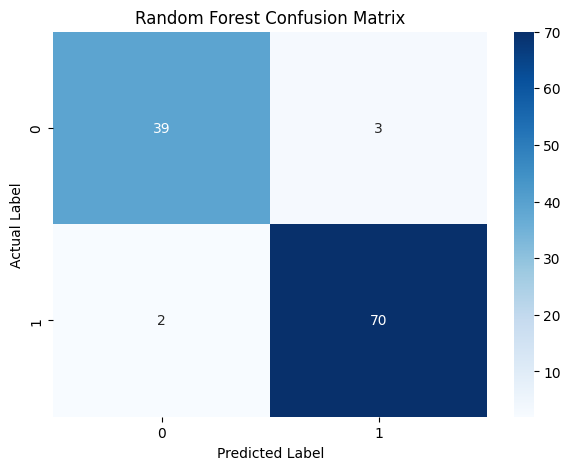

In [5]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(
    y_test,
    forest_pred
)

plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.show()